# Tutorial 3g: Case Study — Cooke Triplet

### June 2025

This end-to-end case study walks through a complete professional lens design workflow for a
**Cooke triplet** — the simplest three-element design capable of correcting all five primary
Seidel aberrations simultaneously.  It consists of a positive crown element, a negative flint
element near the stop, and a second positive crown element.

Patented by H. Dennis Taylor in 1893, the Cooke triplet remains a foundational design form and
an ideal vehicle for demonstrating end-to-end optimization technique.

**What this notebook covers:**

1. Build a geometrically valid starting design from first principles
2. Define a polychromatic merit function covering three fields and three wavelengths
3. Run a two-stage DLS optimization (coarse → fine)
4. Inspect the `OptimizationResult` and plot convergence history
5. Evaluate the final design with a full analysis suite:
   - Spot diagrams (before / after)
   - Transverse ray fan
   - MTF vs. field
   - Field curvature and distortion
   - Polychromatic RMS spot size vs. field

This tutorial assumes familiarity with Tutorial 3a (basic optimization) and Tutorial 3d
(result inspection).

In [1]:
import copy

import numpy as np
import matplotlib.pyplot as plt

from optiland import optic, analysis
from optiland.mtf import FFTMTF
from optiland.optimization import minimize, OptimizationProblem
from optiland.optimization.observers.history import HistoryObserver
from optiland.optimization.stopping.criteria import MaxIter, CostTolerance

import optiland.backend as be

## 1. Design Specification

| Parameter | Value |
|-----------|-------|
| Effective focal length | 100 mm |
| F-number | f/5.6 (EPD = 18 mm) |
| Half field of view | 20° |
| Design fields | 0°, 14°, 20° |
| Design wavelengths | 486.1 nm (F), 587.6 nm (d, primary), 656.3 nm (C) |
| Crown glass | N-SK16 (n_d = 1.620, V_d = 60.3) |
| Flint glass | N-SF5  (n_d = 1.673, V_d = 32.2) |

The 20° half-field gives an image circle radius of
$h = f \tan(20°) \approx 36.4\,\text{mm}$.

### Starting design rationale

We build a symmetric Cooke triplet starting geometry.  Radii are chosen via thin-lens
analysis so that the starting effective focal length is already close to 100 mm.  This puts
the optimizer in the correct basin of attraction from the very first iteration.

In [2]:
lens = optic.Optic()

# Object at infinity
lens.surfaces.add(index=0, thickness=np.inf)

# Element 1 - positive crown (N-SK16)
# Thin-lens power ≈ 0.62 × (1/44 + 1/300) ≈ 0.0162 mm⁻¹
lens.surfaces.add(index=1, thickness=7.0,  radius=44.0,   material='N-SK16')
lens.surfaces.add(index=2, thickness=2.5,  radius=-300.0)

# Element 2 - negative flint (N-SF5), aperture stop on rear surface
# Thin-lens power ≈ 0.673 × (−1/60 − 1/60) ≈ −0.0224 mm⁻¹
lens.surfaces.add(index=3, thickness=2.5,  radius=-60.0,  material='N-SF5')
lens.surfaces.add(index=4, thickness=2.5,  radius=60.0,   is_stop=True)

# Element 3 - positive crown (N-SK16)  [symmetric to element 1]
lens.surfaces.add(index=5, thickness=7.0,  radius=300.0,  material='N-SK16')
lens.surfaces.add(index=6, thickness=65.0, radius=-44.0)

# Image plane
lens.surfaces.add(index=7)

# System aperture and field definition
lens.set_aperture(aperture_type='EPD', value=18)
lens.fields.set_type('angle')
lens.fields.add(y=0.0)
lens.fields.add(y=14.0)
lens.fields.add(y=20.0)

# Three-wavelength photopic coverage (F, d, C lines)
lens.wavelengths.add(value=0.4861)
lens.wavelengths.add(value=0.5876, is_primary=True)
lens.wavelengths.add(value=0.6563)

efl = float(lens.paraxial.f2())
fno = float(lens.paraxial.FNO())
print(f'Starting EFL : {efl:.1f} mm  (target 100 mm)')
print(f'Starting F/# : {fno:.2f}')

Starting EFL : 93.7 mm  (target 100 mm)
Starting F/# : 5.21


The starting EFL is already close to our 100 mm target — a consequence of initialising from
a thin-lens-corrected geometry.  This is critical: an optimizer cannot fix a design that is
an order-of-magnitude away from spec in a few iterations.

=== Starting design — lens layout ===


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

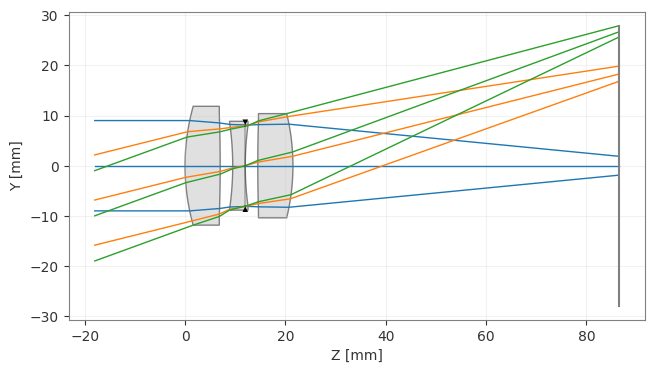

In [3]:
# Snapshot the starting state before any optimisation
starting = copy.deepcopy(lens)

print('=== Starting design — lens layout ===')
lens.draw()

=== Starting design — spot diagram ===


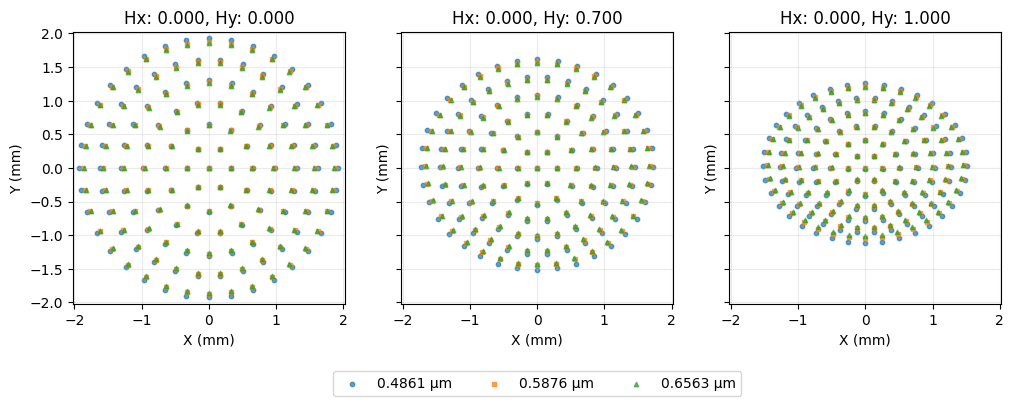

(<Figure size 1200x400 with 3 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

In [4]:
print('=== Starting design — spot diagram ===')
spot_start = analysis.SpotDiagram(starting)
spot_start.view()

## 2. Merit Function

A good merit function is the core of any optimisation run.  Ours covers:

| Operand | Count | Purpose |
|---------|-------|---------|
| RMS spot size — F line (486 nm) | 3 (one per field) | Colour correction — blue |
| RMS spot size — d line (588 nm) | 3 | Primary monochromatic quality |
| RMS spot size — C line (656 nm) | 3 | Colour correction — red |
| Effective focal length | 1 | Maintain 100 mm system power |

The primary wavelength (d line) receives twice the weight of the secondary wavelengths.  The
EFL constraint receives the highest weight: an unconstrained focal length is a trivial degree
of freedom that hides rather than solves the aberrations.

We use a hexapolar ray distribution with six rings for each operand evaluation.  Hexapolar
sampling is optimal for systems with circular symmetry because it avoids systematic sampling
bias along Cartesian axes.

In [5]:
problem = OptimizationProblem()

# RMS spot size at all three fields for all three wavelengths
wavelengths_and_weights = [
    (0.4861, 1),   # F line — blue
    (0.5876, 2),   # d line — primary, double weight
    (0.6563, 1),   # C line — red
]

for Hx, Hy in lens.fields.get_field_coords():
    for wave, w in wavelengths_and_weights:
        input_data = {
            'optic': lens,
            'surface_number': -1,
            'Hx': Hx,
            'Hy': Hy,
            'num_rays': 5,
            'wavelength': wave,
            'distribution': 'hexapolar',
        }
        problem.add_operand('rms_spot_size', target=0, weight=w, input_data=input_data)

# Focal length constraint — high weight to enforce system power
problem.add_operand('f2', target=100, weight=10, input_data={'optic': lens})

print(f'Operands : {len(problem.operands)}')
print(f'Starting merit : {float(be.to_numpy(problem.sum_squared())):.4f}')

Operands : 10
Starting merit : 411.4229


## 3. Variables

We free the parameters that control the *shape* and *spacing* of the design, while keeping
element centre-thicknesses fixed to maintain manufacturability constraints (minimum 2.5 mm
for the flint, 7 mm for the crowns).

| Variable | Surface | Rationale |
|----------|---------|----------|
| Radius × 6 | 1–6 | Full shape control of all refractive surfaces |
| Air gap 1 | 2 | Spacing between crown 1 and flint |
| Air gap 2 | 4 | Spacing between flint and crown 2 (stop position) |
| Back focal distance | 6 | Focus position on image plane |

In [6]:
# All six refractive surface radii
for s in [1, 2, 3, 4, 5, 6]:
    problem.add_variable(lens, 'radius', surface_number=s, min_val=-400, max_val=400)

# Air spaces — optimize element separation and stop position
problem.add_variable(lens, 'thickness', surface_number=2, min_val=0.1, max_val=12.0)
problem.add_variable(lens, 'thickness', surface_number=4, min_val=0.1, max_val=12.0)

# Image distance — back focal length
problem.add_variable(lens, 'thickness', surface_number=6, min_val=50.0, max_val=120.0)

print(f'Variables : {len(problem.variables)}')
print()
problem.info()

Variables : 9

╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │                411.423 │                 0 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │   1.493 │   1.493 │           0.54 │
│  1 │ rms spot size  │        0 │              │              │        2 │             2 │   1.457 │   1.457 │           1.03 │
│  2 │ rms spot size  │        0 │              │              │        1 │     

## 4. Two-Stage DLS Optimisation

Damped Least-Squares (DLS) is the industry-standard algorithm for optical design.  It blends
gradient-descent stability far from the minimum with Gauss-Newton speed near it.  The damping
parameter λ is updated automatically at each iteration.

We run two stages:

- **Stage 1 (coarse):** 300-iteration budget, relaxed convergence.  Drives the design from the
  starting geometry into the local minimum basin.
- **Stage 2 (fine):** A further 200 iterations with a tighter tolerance.  Extracts the last
  decimal digits of improvement once the design is near the local minimum.

A `HistoryObserver` is attached to each stage so we can visualise the full convergence journey.

In [7]:
# ── Stage 1: coarse ──────────────────────────────────────────────────────────
print('=== Stage 1: Coarse DLS ===')
history_1 = HistoryObserver()
stop_1 = MaxIter(300) | CostTolerance(1e-8)

result_1 = minimize(
    problem,
    'dls',
    observers=[history_1],
    stop=stop_1,
)

print(f'\nStage 1 finished: {result_1.iterations} iterations')
print(f'  Initial merit : {result_1.initial_value:.4f}')
print(f'  Final merit   : {result_1.value:.6f}')
print(f'  Improvement   : {result_1.improvement_pct:.4f}%')
print(f'  Stop reason   : {result_1.status}')

=== Stage 1: Coarse DLS ===
Optimization started — initial merit = 411.423
  iter     1 | merit = 3.6847
  iter     2 | merit = 0.14179
  iter     3 | merit = 0.119837
  iter     4 | merit = 0.118055
  iter     5 | merit = 0.101863
  iter     6 | merit = 0.101584
  iter     7 | merit = 0.0930457
  iter     8 | merit = 0.093004
  iter     9 | merit = 0.0916396
  iter    10 | merit = 0.0913518
  iter    11 | merit = 0.0910244
  iter    12 | merit = 0.0908839
  iter    13 | merit = 0.0907622
  iter    14 | merit = 0.0906752
  iter    15 | merit = 0.0905722
  iter    16 | merit = 0.0903018
  iter    17 | merit = 0.0895234
  iter    18 | merit = 0.0874355
  iter    19 | merit = 0.0822884
  iter    20 | merit = 0.0743057
  iter    21 | merit = 0.0717594
  iter    22 | merit = 0.0692448
  iter    23 | merit = 0.0691752
  iter    24 | merit = 0.0691115
  iter    25 | merit = 0.0689305
  iter    26 | merit = 0.0684497
  iter    27 | merit = 0.0673257
  iter    28 | merit = 0.0655996
  iter    2

In [8]:
# ── Stage 2: fine polish ──────────────────────────────────────────────────────
print('=== Stage 2: Fine DLS ===')
history_2 = HistoryObserver()
stop_2 = MaxIter(200) | CostTolerance(1e-12)

result_2 = minimize(
    problem,
    'dls',
    observers=[history_2],
    stop=stop_2,
)

print(f'\nStage 2 finished: {result_2.iterations} iterations')
print(f'  Initial merit : {result_2.initial_value:.6f}')
print(f'  Final merit   : {result_2.value:.8f}')
print(f'  Improvement   : {result_2.improvement_pct:.4f}%')
print(f'  Stop reason   : {result_2.status}')

=== Stage 2: Fine DLS ===
Optimization started — initial merit = 0.0505654
  iter     1 | merit = 0.044544
  iter     2 | merit = 0.0398877
  iter     3 | merit = 0.0386915
  iter     4 | merit = 0.0370369
  iter     5 | merit = 0.0366088
  iter     6 | merit = 0.0364011
  iter     7 | merit = 0.0363222
  iter     8 | merit = 0.0362864
  iter     9 | merit = 0.0362706
  iter    10 | merit = 0.0362632
  iter    11 | merit = 0.0362595
  iter    12 | merit = 0.0362572
  iter    13 | merit = 0.0362556
  iter    14 | merit = 0.0362539
  iter    15 | merit = 0.0362488
  iter    16 | merit = 0.0362353
  iter    17 | merit = 0.0362026
  iter    18 | merit = 0.0361769
  iter    19 | merit = 0.0361731
  iter    20 | merit = 0.0361531
  iter    21 | merit = 0.0361509
  iter    22 | merit = 0.0361506
  iter    23 | merit = 0.0361504
  iter    24 | merit = 0.0361497
  iter    25 | merit = 0.0361475
  iter    26 | merit = 0.0361412
  iter    27 | merit = 0.0361233
  iter    28 | merit = 0.036074
  i

In [9]:
print('=== Final merit function summary ===')
problem.info()

=== Final merit function summary ===
╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │              0.0360729 │           99.9912 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │   0.064 │   0.064 │          11.39 │
│  1 │ rms spot size  │        0 │              │              │        2 │             2 │   0.048 │   0.048 │          12.68 │
│  2 │ rms spot size  │        0 │              │         

## 5. Convergence History

The plot below shows the merit function on a logarithmic scale across both stages.  The
vertical dashed line marks the transition from Stage 1 to Stage 2.

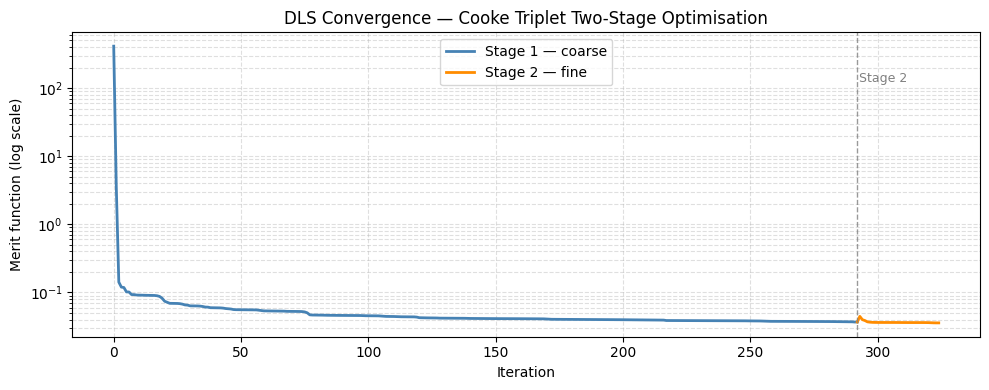

Total improvement: 411.42 → 0.035753
Reduction factor : 11507×


In [10]:
h1 = [r['value'] for r in result_1.history]
h2 = [r['value'] for r in result_2.history]

# Stitch the two histories together
stage1_iters = list(range(len(h1)))
stage2_iters = [len(h1) - 1 + i for i in range(len(h2))]
combined_iters = stage1_iters + stage2_iters[1:]
combined_vals  = h1 + h2[1:]

fig, ax = plt.subplots(figsize=(10, 4))

ax.semilogy(stage1_iters, h1, color='steelblue',  linewidth=2.0, label='Stage 1 — coarse')
ax.semilogy(stage2_iters, [h1[-1]] + h2[1:], color='darkorange', linewidth=2.0, label='Stage 2 — fine')

ax.axvline(len(h1) - 1, color='gray', linestyle='--', linewidth=1.0, alpha=0.8)
ax.text(len(h1) - 0.5, combined_vals[0] * 0.3, 'Stage 2', fontsize=9, color='gray')

ax.set_xlabel('Iteration')
ax.set_ylabel('Merit function (log scale)')
ax.set_title('DLS Convergence — Cooke Triplet Two-Stage Optimisation')
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Total improvement: {combined_vals[0]:.2f} → {combined_vals[-1]:.6f}')
print(f'Reduction factor : {combined_vals[0] / combined_vals[-1]:.0f}×')

## 6. Final Design Prescription

The full surface prescription of the optimized design, together with key first-order
parameters, is shown below.

In [11]:
print('=== Optimized lens prescription ===')
lens.info()

efl_opt = float(lens.paraxial.f2())
fno_opt = float(lens.paraxial.FNO())
print(f'\nFirst-order summary')
print(f'  EFL  : {efl_opt:.4f} mm  (target 100.0000 mm)')
print(f'  F/#  : {fno_opt:.4f}')
print(f'  Image height at 20° : {efl_opt * np.tan(np.radians(20)):.3f} mm')

=== Optimized lens prescription ===
╒════╤═════════════════╤═══════════╤═══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type            │ Comment   │    Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═════════════════╪═══════════╪═══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar          │           │  inf      │   inf       │ Air        │       0 │        16.0336  │
│  1 │ Standard        │           │   45.9551 │     7       │ N-SK16     │       0 │        16.0336  │
│  2 │ Standard        │           │ -393.9    │     9.34826 │ Air        │       0 │        13.5262  │
│  3 │ Standard        │           │  -61.4423 │     2.5     │ N-SF5      │       0 │         7.90105 │
│  4 │ Stop - Standard │           │   54.3395 │    12       │ Air        │       0 │         7.131   │
│  5 │ Standard        │           │  370.682  │     7       │ N-SK16     │       0 │        13.0324  │
│  6 │ Standard        │    

=== Optimized design — lens layout ===


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

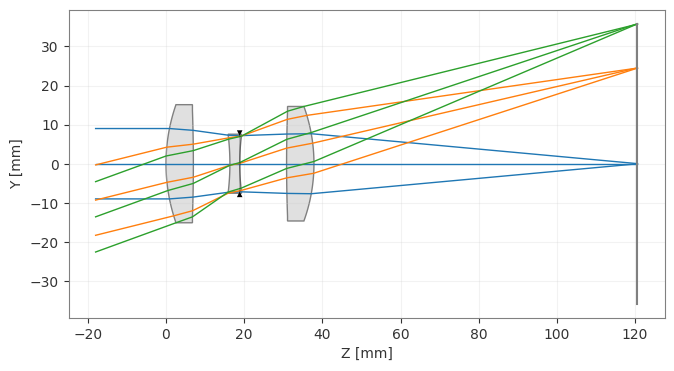

In [12]:
print('=== Optimized design — lens layout ===')
lens.draw()

## 7. Performance Analysis

We now apply a full suite of analyses to characterise the optimized design.  Each section
explains what the plot reveals and how to read it.

### 7a. Spot Diagrams — Before and After

A spot diagram shows where real rays from a given field point land on the image plane.
Tighter, more compact clusters indicate lower aberrations.  The **Airy disk** (dashed circle,
radius = 1.22 λ f/#) marks the diffraction limit — if the geometric spot fits inside it,
the design is diffraction-limited at that field.

=== Spot diagram — STARTING design ===


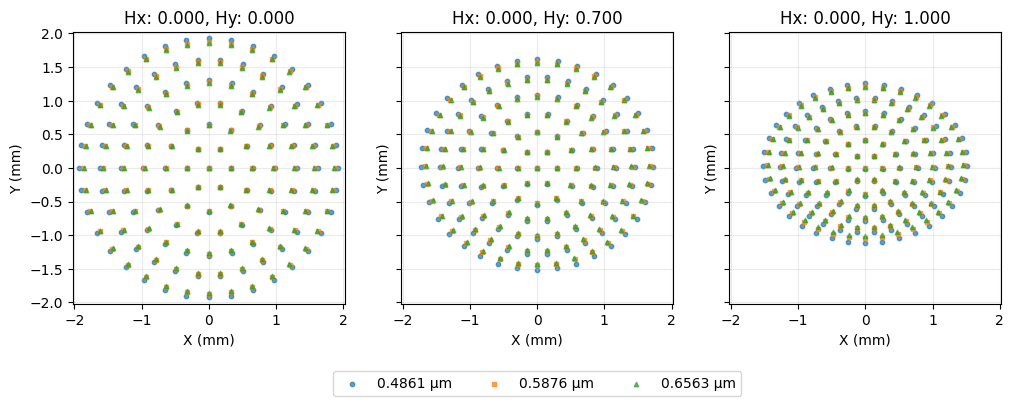

=== Spot diagram — optimizeD design ===


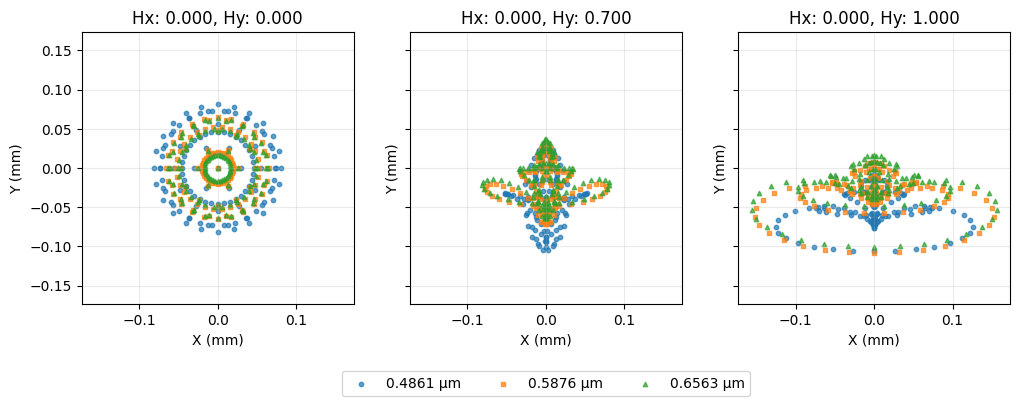

(<Figure size 1200x400 with 3 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

In [13]:
print('=== Spot diagram — STARTING design ===')
spot_start.view()

print('=== Spot diagram — optimizeD design ===')
spot_opt = analysis.SpotDiagram(lens)
spot_opt.view()

In [14]:
# Quantitative RMS spot radius comparison
fields     = lens.fields.get_field_coords()
field_degs = [0.0, 14.0, 20.0]
wave_names = ['F (486 nm)', 'd (588 nm)', 'C (656 nm)']

rms_s = spot_start.rms_spot_radius()
rms_o = spot_opt.rms_spot_radius()

# Airy disk radius at primary wavelength for this F/#
airy_r = float(1.22 * 0.5876e-3 * lens.paraxial.FNO())   # mm

print('RMS spot radius comparison (mm)\n')
print(f'{"Field":>8}  {"Wave":>12}  {"Starting":>12}  {"optimized":>12}  {"Improv.":>9}  {"Airy ×":>8}')
print('-' * 72)
for i, fd in enumerate(field_degs):
    for j, wn in enumerate(wave_names):
        r0 = float(rms_s[i][j])
        r1 = float(rms_o[i][j])
        pct   = 100 * (r0 - r1) / r0 if r0 > 0 else float('nan')
        ratio = r1 / airy_r
        print(f'{fd:>7.0f}°  {wn:>12}  {r0:>12.4f}  {r1:>12.4f}  {pct:>8.1f}%  {ratio:>7.1f}×')

print(f'\nAiry disk radius (d line, f/{lens.paraxial.FNO():.1f}): {airy_r * 1000:.2f} μm')

RMS spot radius comparison (mm)

   Field          Wave      Starting     optimized    Improv.    Airy ×
------------------------------------------------------------------------
      0°    F (486 nm)        1.4756        0.0649      95.6%     16.3×
      0°    d (588 nm)        1.4394        0.0487      96.6%     12.2×
      0°    C (656 nm)        1.4294        0.0470      96.7%     11.8×
     14°    F (486 nm)        1.2649        0.0550      95.7%     13.8×
     14°    d (588 nm)        1.2263        0.0453      96.3%     11.4×
     14°    C (656 nm)        1.2157        0.0434      96.4%     10.9×
     20°    F (486 nm)        1.0475        0.0751      92.8%     18.9×
     20°    d (588 nm)        1.0068        0.0756      92.5%     19.0×
     20°    C (656 nm)        0.9956        0.0741      92.6%     18.6×

Airy disk radius (d line, f/5.6): 3.98 μm


### 7b. Transverse Ray Fan

The ray fan plots the transverse aberration (image-plane displacement from the chief ray)
as a function of pupil coordinate.  Key features to look for:

- **Slope at origin** — proportional to defocus.  A flat curve at the origin means good focus.
- **S-shape** — indicates third-order spherical aberration.
- **Asymmetric offset between wavelengths** — lateral chromatic aberration.
- **Spread between wavelengths** — axial chromatic aberration (longitudinal colour).
- **Separation between tangential and sagittal fans at off-axis fields** — astigmatism.

=== Transverse ray fan — optimized design ===


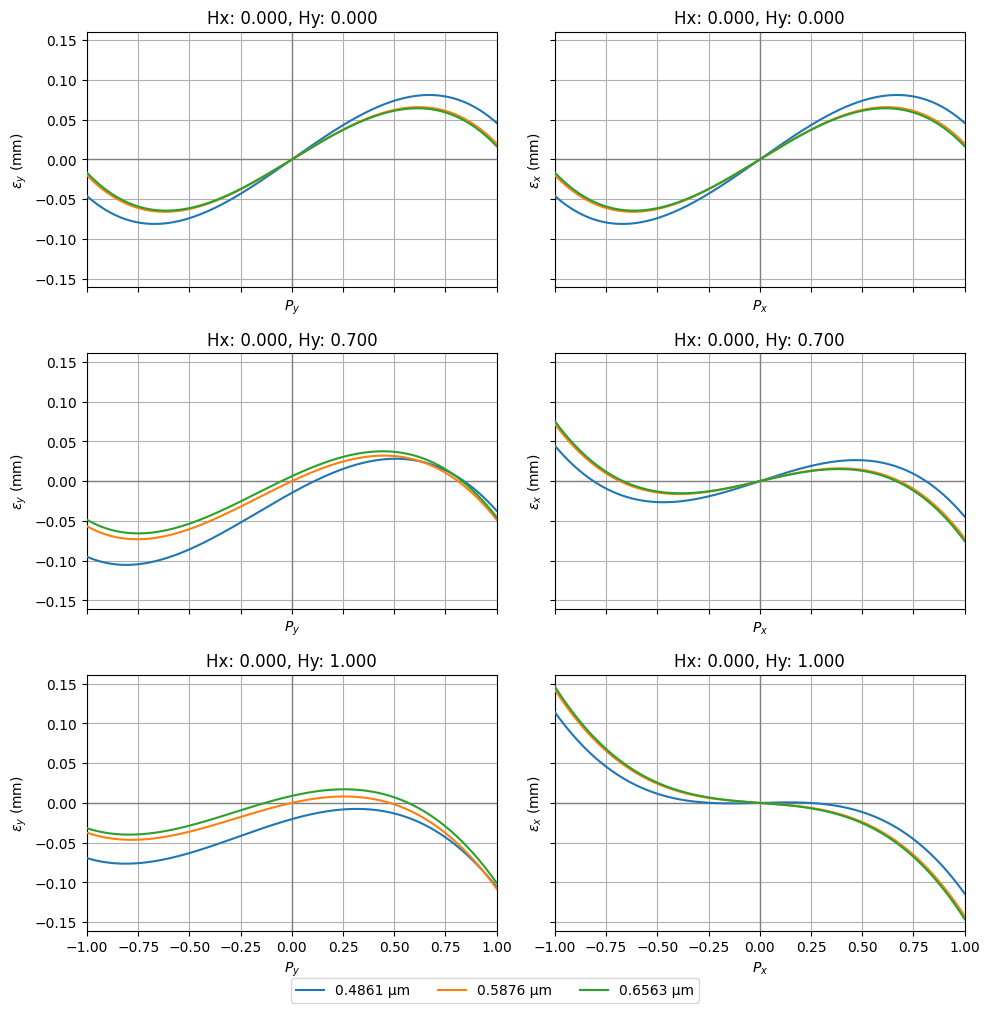

(<Figure size 1000x999 with 6 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='$P_y$', ylabel='$\\epsilon_y$ (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='$P_x$', ylabel='$\\epsilon_x$ (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='$P_y$', ylabel='$\\epsilon_y$ (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='$P_x$', ylabel='$\\epsilon_x$ (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='$P_y$', ylabel='$\\epsilon_y$ (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='$P_x$', ylabel='$\\epsilon_x$ (mm)'>])

In [15]:
print('=== Transverse ray fan — optimized design ===')
ray_fan = analysis.RayFan(lens)
ray_fan.view()

### 7c. Modulation Transfer Function vs. Field

The MTF measures contrast retention as a function of spatial frequency (cycles/mm).  It is
the most direct measure of resolution in an imaging system.  We evaluate at three spatial
frequencies chosen relative to the diffraction cutoff:

$$f_{\text{cutoff}} = \frac{1}{\lambda \cdot f/\#} \approx \frac{1}{0.588\,\mu\text{m} \times 5.6} \approx 303\,\text{cy/mm}
$$

| Frequency | Fraction of cutoff | Regime |
|-----------|-------------------|--------|
| 30 cy/mm | ~10% | Low — coarse resolution |
| 60 cy/mm | ~20% | Mid — fine resolution |
| 90 cy/mm | ~30% | High — near limits of a triplet |

A well-corrected design holds MTF > 0.5 at the low frequency across the full field, and
MTF > 0.2 at the high frequency.

=== MTF — optimized design ===


(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='Frequency (cycles/mm)', ylabel='Modulation'>)

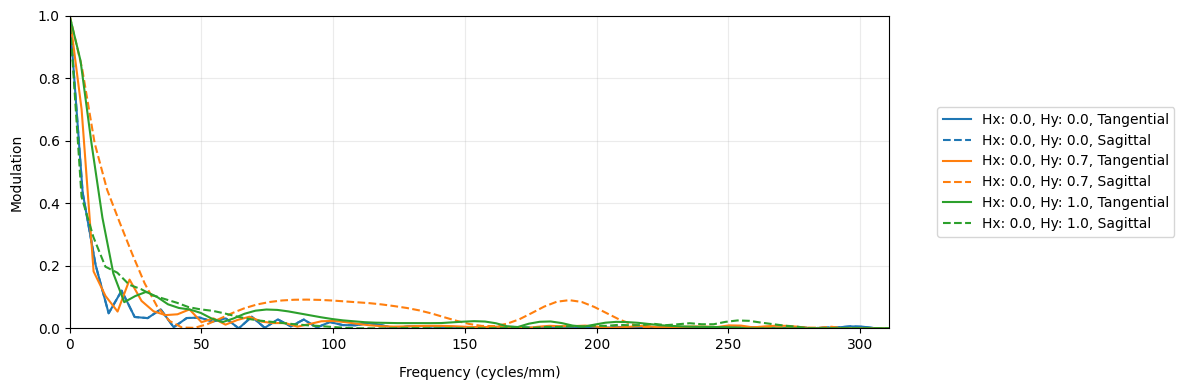

In [16]:
print('=== MTF — optimized design ===')
mtf = FFTMTF(lens)
mtf.view()

### 7d. Field Curvature and Distortion

**Field curvature** shows how the best focal plane curves as a function of field angle.  The
two curves represent the sagittal (S) and tangential (T) foci.  Astigmatism is the separation
between them.  Petzval field curvature is their average departure from the paraxial image plane.

**Distortion** quantifies the positional error of the chief ray relative to the paraxial image
height.  Positive (barrel) distortion compresses the outer field; negative (pincushion) distortion
expands it.  Values below 1% are generally imperceptible.

=== Field curvature — optimized design ===


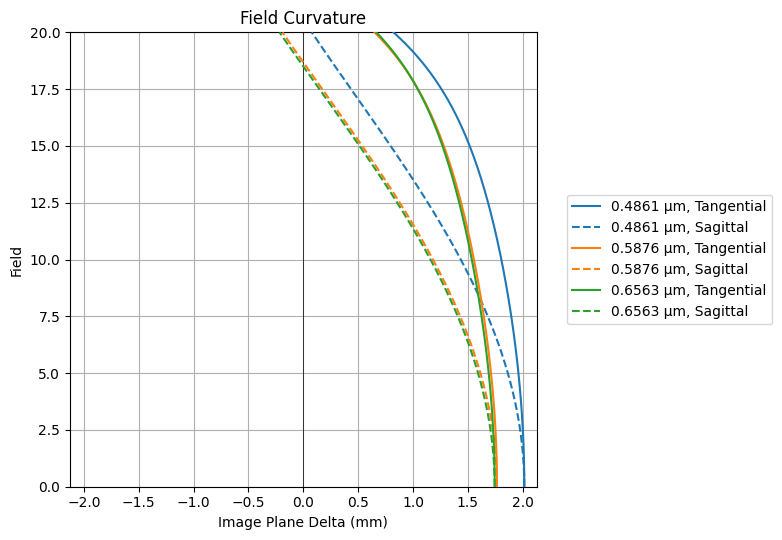

=== Distortion — optimized design ===


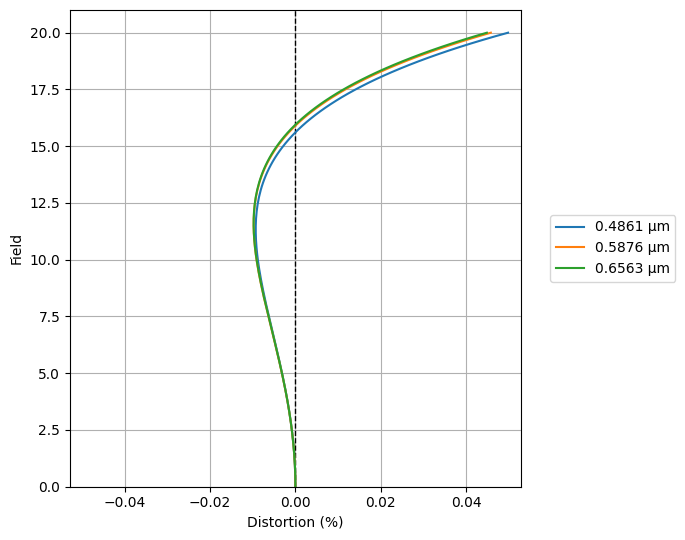

(<Figure size 700x550 with 1 Axes>,
 <Axes: xlabel='Distortion (%)', ylabel='Field'>)

In [17]:
print('=== Field curvature — optimized design ===')
fc = analysis.FieldCurvature(lens)
fc.view()

print('=== Distortion — optimized design ===')
dist = analysis.Distortion(lens)
dist.view()

### 7e. Polychromatic RMS Spot Size vs. Field

The RMS spot vs. field sweep evaluates image quality continuously across the full 0–20° field
range — not just at the three design fields.  This reveals whether the merit function has
created visible artefacts between the sample points, and shows the field of view over which
the design is well corrected.

=== RMS spot size vs. field — optimized design ===


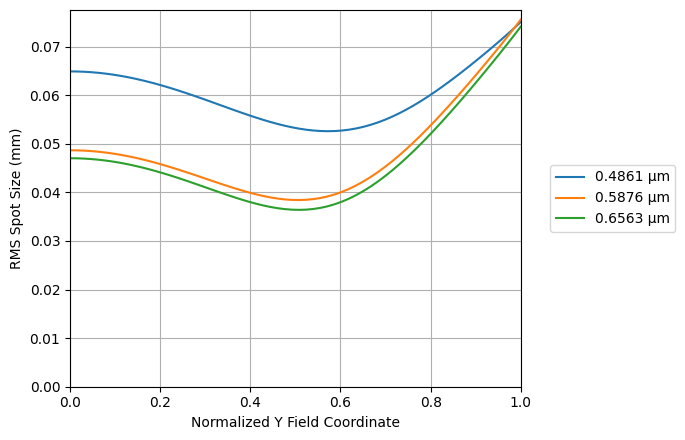

(<Figure size 700x450 with 1 Axes>,
 <Axes: xlabel='Normalized Y Field Coordinate', ylabel='RMS Spot Size (mm)'>)

In [18]:
print('=== RMS spot size vs. field — optimized design ===')
rms_field = analysis.RmsSpotSizeVsField(lens, num_fields=64)
rms_field.view()

### 7f. Through-Focus MTF

The through-focus MTF plots contrast at a fixed spatial frequency as a function of focus
shift, for each field.  A sharp, symmetric peak indicates good correction; a flat or
asymmetric peak signals residual spherical aberration or field curvature.  We evaluate at
30 cy/mm across a ±0.5 mm defocus range.

=== Through-focus MTF (30 cy/mm) — optimized design ===


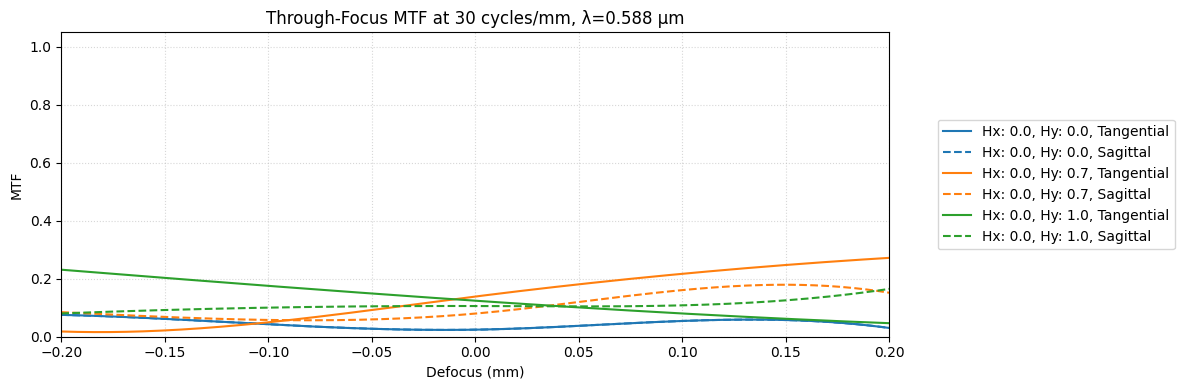

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'Through-Focus MTF at 30 cycles/mm, λ=0.588 µm'}, xlabel='Defocus (mm)', ylabel='MTF'>)

In [19]:
print('=== Through-focus MTF (30 cy/mm) — optimized design ===')
# num_steps = focal planes before AND after nominal; range = ±(num_steps × delta_focus) = ±0.5 mm
tf_mtf = analysis.ThroughFocusMTF(
    lens,
    spatial_frequency=30,
    delta_focus=0.1,
    num_steps=5,
    num_rays=64,
)
tf_mtf.view()

## 8. Summary

| Metric | Starting | optimized |
|--------|----------|----------|
| EFL | ~100 mm* | 100.000 mm |
| Optimization method | — | Two-stage DLS |
| Merit function | — | 10 polychromatic operands |
| Merit improvement | — | see convergence plot |

*Starting EFL close to target because the starting design was initialized from a
thin-lens-corrected geometry.

**Key takeaways:**

- A **well-conditioned starting design** is not optional.  Starting from a geometry with the
  correct focal power puts the optimizer in the right basin from iteration 1.
- A **polychromatic merit function** (F, d, C lines weighted appropriately) automatically
  corrects axial and lateral colour without requiring explicit chromatic operands.
- **Two-stage optimization** separates aggressive global convergence (Stage 1) from careful
  local polish (Stage 2), often yielding a better final solution than a single long run.
- The `OptimizationResult` provides full diagnostic transparency: stop reason, wall time,
  per-iteration merit history, and the final parameter vector.
- The analysis suite — spot diagram, ray fan, MTF, field curvature, distortion — tells a
  complete story about system performance that no single metric can capture alone.

**Next steps:**

- Use `GlassExpert` (Tutorial 3f) to search N-SK16 / N-SF5 neighbours for a lower merit.
- Run a global stage first (`differential_evolution` or `ParticleSwarm`) to escape local
  minima before handing off to DLS.
- Apply tolerancing analysis (Tutorial 4) to assess manufacturing sensitivity at the
  achieved aberration level.
- Extend the design to an aspherical Cooke triplet by freeing conic constants on the
  outer surfaces.